In [1]:
%cd /home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/plastyfire/

/lustre06/project/6077694/dhuruva/plastyfire/plastyfire


In [2]:
import pickle
import numpy as np
import hashlib
import json
import matplotlib.pyplot as plt
import scipy
import pandas as pd
from scipy.optimize import curve_fit
from pathlib import Path

In [ ]:
experiment_folder_path = Path('./')
filename = experiment_folder_path/'checkpoint.pkl'

In [4]:
with open(filename, 'rb') as f:
    data = pickle.load(f)
print(data.keys())

FileNotFoundError: [Errno 2] No such file or directory: 'checkpoint.pkl'

In [ ]:
halloffame = data['halloffame']
best_ind = halloffame[0]
print("Best parameters:", best_ind)
print("Fitness scores:", best_ind.fitness.values)
print("Combined score (norm):", sum(x**2 for x in best_ind.fitness.values)**0.5)

Best parameters: [130.22163278526455, 164.5705233094686, 2.744223297920454, 1.764296838931755, 2.462992578952373, 1.7049097315903299, 7.830216054828284, 3.8700145663207226, 9.835716409493267, 4.395448862865813]
Fitness scores: (0.03562499999999989, 0.027682255845942232, 0.8039137380191694, 2.005791505791506, 0.16666666666666682)
Combined score (norm): 2.167784603823177


In [ ]:
def save_epsp_results(results, output_file="epsp_results.pkl"):
    """Save EPSP computation results to pickle file"""
    with open(output_file, 'wb') as f:
        pickle.dump(results, f)
    print(f"Results saved to {output_file}")

def create_epsp_summary_dataframe(results):
    """Create a pandas DataFrame summary of EPSP results"""
    summary_data = []
    
    for key, result in results.items():
        if 'error' not in result:  # Only include successful computations
            summary_data.append({
                'pre_gid': result['pre_gid'],
                'post_gid': result['post_gid'], 
                'rho_config': result['rho_config'],
                'avg_epsp_mV': result['avg_epsp'],
                'n_epsps': result['n_epsps'],
                'filename': result['filename']
            })
    
    return pd.DataFrame(summary_data)
# epsp_results = True
# # Save results if we have any
# if epsp_results:
#     save_epsp_results(epsp_results)
    
#     # Create summary DataFrame
#     summary_df = create_epsp_summary_dataframe(epsp_results)
#     print("\nEPSP Summary:")
#     print(summary_df)
    
#     # Save summary as CSV
#     summary_df.to_csv("epsp_summary.csv", index=False)
#     print("\nSummary saved to epsp_summary.csv")
# else:
#     print("No EPSP results to save. Run the synapse_combinations_generator.py first to create pickle files.")


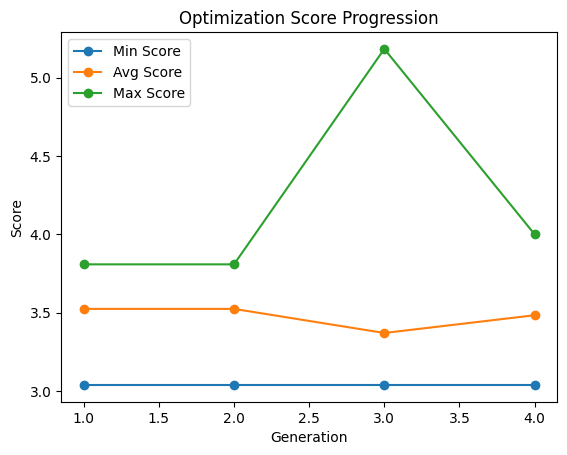

In [ ]:
import matplotlib.pyplot as plt

logbook = data['logbook']
gens = logbook.select("gen")
min_scores = logbook.select("min")
avg_scores = logbook.select("avg")
max_scores = logbook.select("max")

plt.figure()
plt.plot(gens, min_scores, 'o-', label="Min Score")
plt.plot(gens, avg_scores, 'o-', label="Avg Score")
plt.plot(gens, max_scores, 'o-', label="Max Score")
plt.xlabel("Generation")
plt.ylabel("Score")
plt.legend()
plt.title("Optimization Score Progression")
plt.show()

In [6]:
sim_idx = pd.read_csv("/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n100/seed19091997/index_L5TTPC_L5TTPC.csv")
sim_idx.set_index(["frequency", "dt"], inplace=True)
sim_idx.sort_index(inplace=True)

In [7]:
sim_idx

pregid  postgid  \
frequency dt                       
2.0       -10.0  205559   199162   
          -10.0  180723   207048   
          -10.0  185875   206473   
          -10.0  193467   199529   
          -10.0  185785   189513   
...                 ...      ...   
40.0       10.0  182581   208651   
           10.0  194532   187415   
           10.0  208093   203811   
           10.0  184709   196154   
           10.0  193709   181631   

                                                              path  
frequency dt                                                        
2.0       -10.0  /home/dhuruva/projects/ctb-emuller/dhuruva/pla...  
          -10.0  /home/dhuruva/projects/ctb-emuller/dhuruva/pla...  
          -10.0  /home/dhuruva/projects/ctb-emuller/dhuruva/pla...  
          -10.0  /home/dhuruva/projects/ctb-emuller/dhuruva/pla...  
          -10.0  /home/dhuruva/projects/ctb-emuller/dhuruva/pla...  
...                                                            ...  
40.0       10.0  /home/dhuruva/projects/ctb-emuller/dhuruva/pla...  
           10.0  /home/dhuruva/projects/ctb-emuller/dhuruva/pla...  
           10.0  /home/dhuruva/projects/ctb-emuller/dhuruva/pla...  
           10.0  /home/dhuruva/projects/ctb-emuller/dhuruva/pla...  
           10.0  /home/dhuruva/projects/ctb-emuller/dhuruva/pla...  

[1800 rows x 3 columns]

In [9]:
paths = sim_idx.loc[5,5]["path"]
paths

frequency  dt 
5.0        5.0    /home/dhuruva/projects/ctb-emuller/dhuruva/pla...
           5.0    /home/dhuruva/projects/ctb-emuller/dhuruva/pla...
           5.0    /home/dhuruva/projects/ctb-emuller/dhuruva/pla...
           5.0    /home/dhuruva/projects/ctb-emuller/dhuruva/pla...
           5.0    /home/dhuruva/projects/ctb-emuller/dhuruva/pla...
                                        ...                        
           5.0    /home/dhuruva/projects/ctb-emuller/dhuruva/pla...
           5.0    /home/dhuruva/projects/ctb-emuller/dhuruva/pla...
           5.0    /home/dhuruva/projects/ctb-emuller/dhuruva/pla...
           5.0    /home/dhuruva/projects/ctb-emuller/dhuruva/pla...
           5.0    /home/dhuruva/projects/ctb-emuller/dhuruva/pla...
Name: path, Length: 100, dtype: object

In [8]:
np.shape(results_dict['rho_GB'])

NameError: name 'results_dict' is not defined

In [21]:
np.max(results_dict['t'])

1350000.0

initial rho_GB
0 0 1 0 0 0 0 1 
final rho_GB
0 0 0 0 0 0 0 0 

Text(0.5, 1.0, 'Rho')

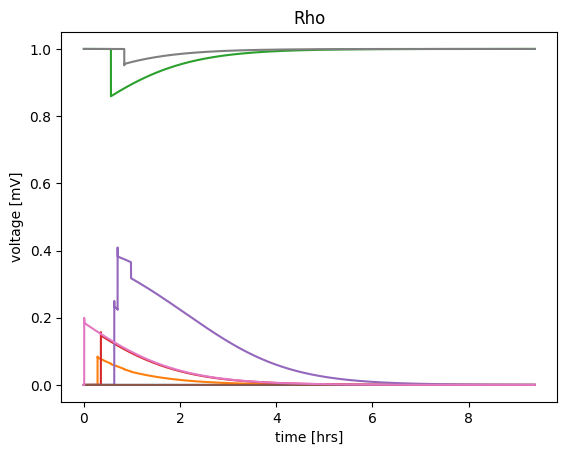

In [23]:
# plotting the rho_GB
file_path_rho_GB = "/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n100/seed19091997/L23PC_L5TTPC/simulations/20129-181038/50Hz_10ms/simulation_20333abf369f.pkl"

with open(file_path_rho_GB, 'rb') as f:
    results_dict = pickle.load(f)

#plt.plot(results_dict['rho_GB'])

print("initial rho_GB")
for key in range(len(results_dict['rho_GB'].T)):
    print(int(results_dict['rho_GB'].T[key][0]), end=" ")
print("\nfinal rho_GB")
for key in range(len(results_dict['rho_GB'].T)):
    print(int(results_dict['rho_GB'].T[key][-1]), end=" ")
plt.plot(np.array(results_dict['t'])*0.025/60/60, results_dict['rho_GB'])
plt.xlabel('time [hrs]')
plt.ylabel('voltage [mV]')
plt.title("Rho")

In [8]:
file_path = "/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n1/seed19091997/L5TTPC_L5TTPC/simulations/205559-199162/5Hz_5ms/simulation_872a4f3ab18a.pkl"

with open(file_path, 'rb') as f:
    results_dict = pickle.load(f)

print(results_dict.keys())

dict_keys(['t', 'v', 'prespikes', 'postspikes', 'synprop', 'rho_GB', 'Use_GB', 'gmax_AMPA', 'cai_CR', 'vsyn', 'ica_NMDA', 'ica_VDCC', 'effcai_GB'])


In [ ]:
results_dict['rho_GB'][0]

In [ ]:
results_dict['rho_GB'][-1]

In [ ]:
plt.plot(results_dict['rho_GB'])

In [ ]:
file_path = "/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n1/seed19091997/ephys_data/ephys_data_205559_199162_0_0_0_0_0_0_0_0.pkl"

with open(file_path, 'rb') as f:
    saved_ephys_data = pickle.load(f)

print(saved_ephys_data.keys())

In [ ]:
from plastyfire.ephysutils import Experiment

In [ ]:
from plastyfire.ephysutils import get_epsp_vector

In [ ]:
def compute_epsp_safe(pkl_file, window=100):
    """Safely compute EPSP values with bounds checking (8 lines)"""
    with open(pkl_file, 'rb') as f:
        data = pickle.load(f)
    try:
        t, v, spikes = data['t'], data['v'], data['pre_spikes']
    except:
        t, v, spikes = data['t'], data['v'], data['prespikes']
    
    # Set numpy print options to show full arrays
    np.set_printoptions(threshold=np.inf, linewidth=np.inf)
    if len(data['rho_GB']) > 100:
        #transponse the matrix
        data['rho_GB'] = np.transpose(data['rho_GB'])
        
    print("initial rho_GB", [0 if k[0] < 0.5 else 1 for k in data['rho_GB']])
    # if val<0.5 then val = 0 else val = 1
    print("final rho_GB", [0 if k[-1] < 0.5 else 1 for k in data['rho_GB']])
    # Reset numpy print options to default
    np.set_printoptions(threshold=1000, linewidth=75)
    
    valid_spikes = spikes[spikes < (t[-1] - window)][:60]  # Only spikes with full window
    #print(spikes)
    #print(valid_spikes)
    
    
    print(len(spikes), len(valid_spikes), len(t))
    if len(t)>237823:
        #compute epsp_ratio and print it
        epsp_values_before = get_epsp_vector(t, v, spikes[:60], window)
        epsp_values_after = get_epsp_vector(t, v, spikes[-60:], window)
        epsp_ratio =  np.mean(epsp_values_after)/np.mean(epsp_values_before)
        print("avg epsp_value_before", np.mean(epsp_values_before))
        print("avg epsp_value_after", np.mean(epsp_values_after))
        print("epsp_ratio", epsp_ratio)
        avg_epsp = 0
        epsp_values = 0
    else:
        epsp_values = get_epsp_vector(t, v, valid_spikes, window)  
        avg_epsp = np.mean(epsp_values) if len(epsp_values) > 0 else 0.0

    return epsp_values, avg_epsp, len(valid_spikes), len(spikes), t, v, data

In [ ]:
#[1, 1, 0, 1, 1, 0, 0, 1]
file_path = "/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n1/seed19091997/L5TTPC_L5TTPC/simulations/205559-199162/5Hz_5ms/simulation_872a4f3ab18a.pkl"

epsps2, actual_epsp_before, valid2, total2,t3, v3, actual_data = compute_epsp_safe(file_path)
actual_epsp_before

In [ ]:
file_path2 = "/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n1/seed19091997/ephys_data/ephys_data_205559_199162_1_1_0_1_0_0_1_1.pkl"
epsps2, expected_epsp_before, valid2, total2,t2, v2, expected_before_data = compute_epsp_safe(file_path2)
expected_epsp_before

In [ ]:
file_path1 = "/home/dhuruva/projects/ctb-emuller/dhuruva/plastyfire/refitting_results/fitting/n1/seed19091997/ephys_data/ephys_data_205559_199162_1_1_0_1_1_0_1_1.pkl"
epsps1, expected_epsp_after, valid1, total1,t_e_after, v_e_after, expected_after_data = compute_epsp_safe(file_path1)
expected_epsp_after

In [ ]:
expected_epsp_ratio = expected_epsp_after/expected_epsp_before
expected_epsp_ratio

In [ ]:
plt.plot(t2, v2, label="expected_epsp_before")
plt.plot(t3, v3, alpha=0.5, label="actual_epsp_before")
plt.axis([0, 247000, -80, -60])
plt.legend()

In [ ]:
plt.plot(t_e_after+280000, v_e_after, label="expected_epsp_after")
plt.plot(t3, v3, alpha=0.5, label="actual_epsp_after")
plt.axis([250000, 370000, -80, -60])
#plt.scatter(expected_after_data['pre_spikes'],[-65]*len(expected_after_data['pre_spikes']))
plt.scatter(expected_after_data['pre_spikes'][-60:],[-65]*len(expected_after_data['pre_spikes'][-60:]))
plt.legend()
